# Part A: Building point-based validation metrics

## Objective
Given a WRF grid cell and its nearest Fire Emergency New Zealand weather station,
build validation toolkit to calculate validation metrics illustrated in the reading material
handout. The coefficient of determination, root mean square error, and the index of
agreement. The meteorological variables we will be validating for are wind speed, air
temperature, and relative humidity. Produce a well commented (using markdown and in-cell
comments) Jupyter notebook sections that full fill the following requirements.
1. For your observational stations you will use two FENZ weather station locations.
a. Godley Head (a coastal site in Canterbury with complex topography)
b. Darfield, Forest Plains (a flat terrain site inland Canterbury)
2. Use a week of your choice in January and a week in July to extract the time series from a WRF
grid point and the nearest FENZ weather station. Your choice of the week and year should
ensure data availability from the weather station (real data will have data availability issues,
double check your choice)
3. Write code that calculates the RMSE, IOA, and R-square validation metrics. Your n (refer to the
reading material document) should be the total number of observations in the week period.
Report your results using a table.
4. Produce time series plots of observed and modelled meteorological variables at both
locations. Your plots should demonstrate a one to one comparison and their objective is to
visualize the trend and biases while investigating the actual data without summary error
statistics yet. Describe and discuss your results.
5. Produce scatter plots of observed and modelled meteorological variables for both locations.
Add a linear trend line that best fits the data points and report the equation of the line. For
reference this is similar to the green lines in the case studies presented in the reading material
handout. Describe and discuss your results.

* One weather station will probably perform better than the other
* Godley Head was chosen because of its complex terrain
* The weather model has 4km resolution but the GH headland is only 1.3km across so the resolution probably won't accurately represent it
* Wind Atlas - resource for 1km wind model


NEW Stations:

Southbridge 02139bfc0beb28e0229b756e 172.25856, -43.84945
Glentanner b1ccc6ead3273d01c94501bd  170.12862, -43.91498

### Import libraries

In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import xarray as xr
from tethysts import Tethys # import the Tethys class
import tethys_helper
import os
from time import time
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

### Define constants

In [5]:
OWNER = "FENZ"

SOUTHBRIDGE = {
    'filename': "southbridge_aws.nc",
    'station_id': "02139bfc0beb28e0229b756e",
    'location': { 'lon': 172.25856, 'lat': -43.84945 }
}
GLENTANNER = {
    'filename': "glentanner_aws.nc",
    'station_id': "b1ccc6ead3273d01c94501bd",
    'location': { 'lon': 170.12862, 'lat': -43.91498 }
}
STATIONS = {
    'Southbridge': SOUTHBRIDGE,
    'Glentanner': GLENTANNER,
}

PARAMETERS = ['wind_speed', 'relative_humidity', 'temperature' ]
VARIABLES = ['wind_speed', 'relative_humidity', 'air_temperature' ]

AXIS_LABEL_FONT_SIZE = 8
TITLE_FONT_SIZE = 12

## Q1: Loading the data

Load the two provided data files into an XArray dataset, and store it in the STATIONS dictionary.

In [9]:
for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]
  dataset = xr.open_dataset(f"./{stn['filename']}")
  stn['dataset'] = dataset

## Q2: Extract time series for January and July

The functinon 'extract_model_series' loads a time slice from the WRF data for a given data type (i.e. 'RH' or 'T') for the given lat/lon location.

In [13]:
def extract_model_series(data_type, start_date, end_date, location, height=2):
    date_obj = datetime.strptime(start_date, "%Y-%m-%d")
    dataset = xr.open_dataset(f"/mnt/data/MetService_WRF/{data_type}_{date_obj.year}{date_obj.month:02d}01000000.nc")
    time_slice = dataset.sel(time=slice(start_date, end_date))
    return time_slice[data_type].sel(height=height, lat=location['lat'], lon=location['lon'], method="nearest")

## Q3: Calculate RMSE, R2 and IOA



In [19]:
def rmse(predictions, observations):
    # sum the squared difference between prediction and observation
    diff = predictions - observations
    sq = [ d**d for d in diff ]
    sum = np.sum(sq)
    # divide by number of observations
    sum_over_n = sum / len(predictions)
    # take the square root
    return np.sqrt(sum_over_n)   

"""
# Test
start_date = "2020-01-06"
end_date = "2020-01-13"

stn = STATIONS['Glentanner']
dataset_observations = stn['dataset']
dataset_predictions = extract_model_series('RH', start_date, end_date, stn['location'])

time_slice_observed = dataset_observations.sel(time=slice(start_date, end_date))
time_slice_predicted = dataset_predictions.sel(time=slice(start_date, end_date))
"""



FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/MetService_WRF/RH_20200101000000.nc'

 ## Q4: Visualise the data

The below function defines a helper to plot both the model and observation data for a given parameter and date range.

In [14]:
def plot_model_vs_observations(model_data, obs_data, key, month, data_type, ax):
    model_data.plot(ax=ax, linestyle="dashed",color="blue",label="Model")
    obs_data.plot(ax=ax, linestyle="dashed",color="orange",label="Observed")
    ax.set_xlabel("Time", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel(data_type, fontsize=AXIS_LABEL_FONT_SIZE)
    #ax.set_xticks(fontsize=AXIS_TICK_FONT_SIZE,rotation=45)
    #ax.set_yticks(fontsize=AXIS_TICK_FONT_SIZE,rotation=0)
    ax.set_title(f"{data_type}, {key}, {month}")
    ax.legend()
    

This function is to calculate overall wind speed from the North-South and the East-West wind speed values.

In [15]:
def calc_wind_speed(u, v):
  usqr = u ** 2
  vsqr = u ** 2
    
  # Wind speed calculation is the square root of the sum of the squares
  return np.sqrt(usqr + vsqr)

Generate the comparison plots. Chosen weeks are the week starting Jan 6th 2020, and the week starting July 10th 2019.

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/MetService_WRF/RH_20200101000000.nc'

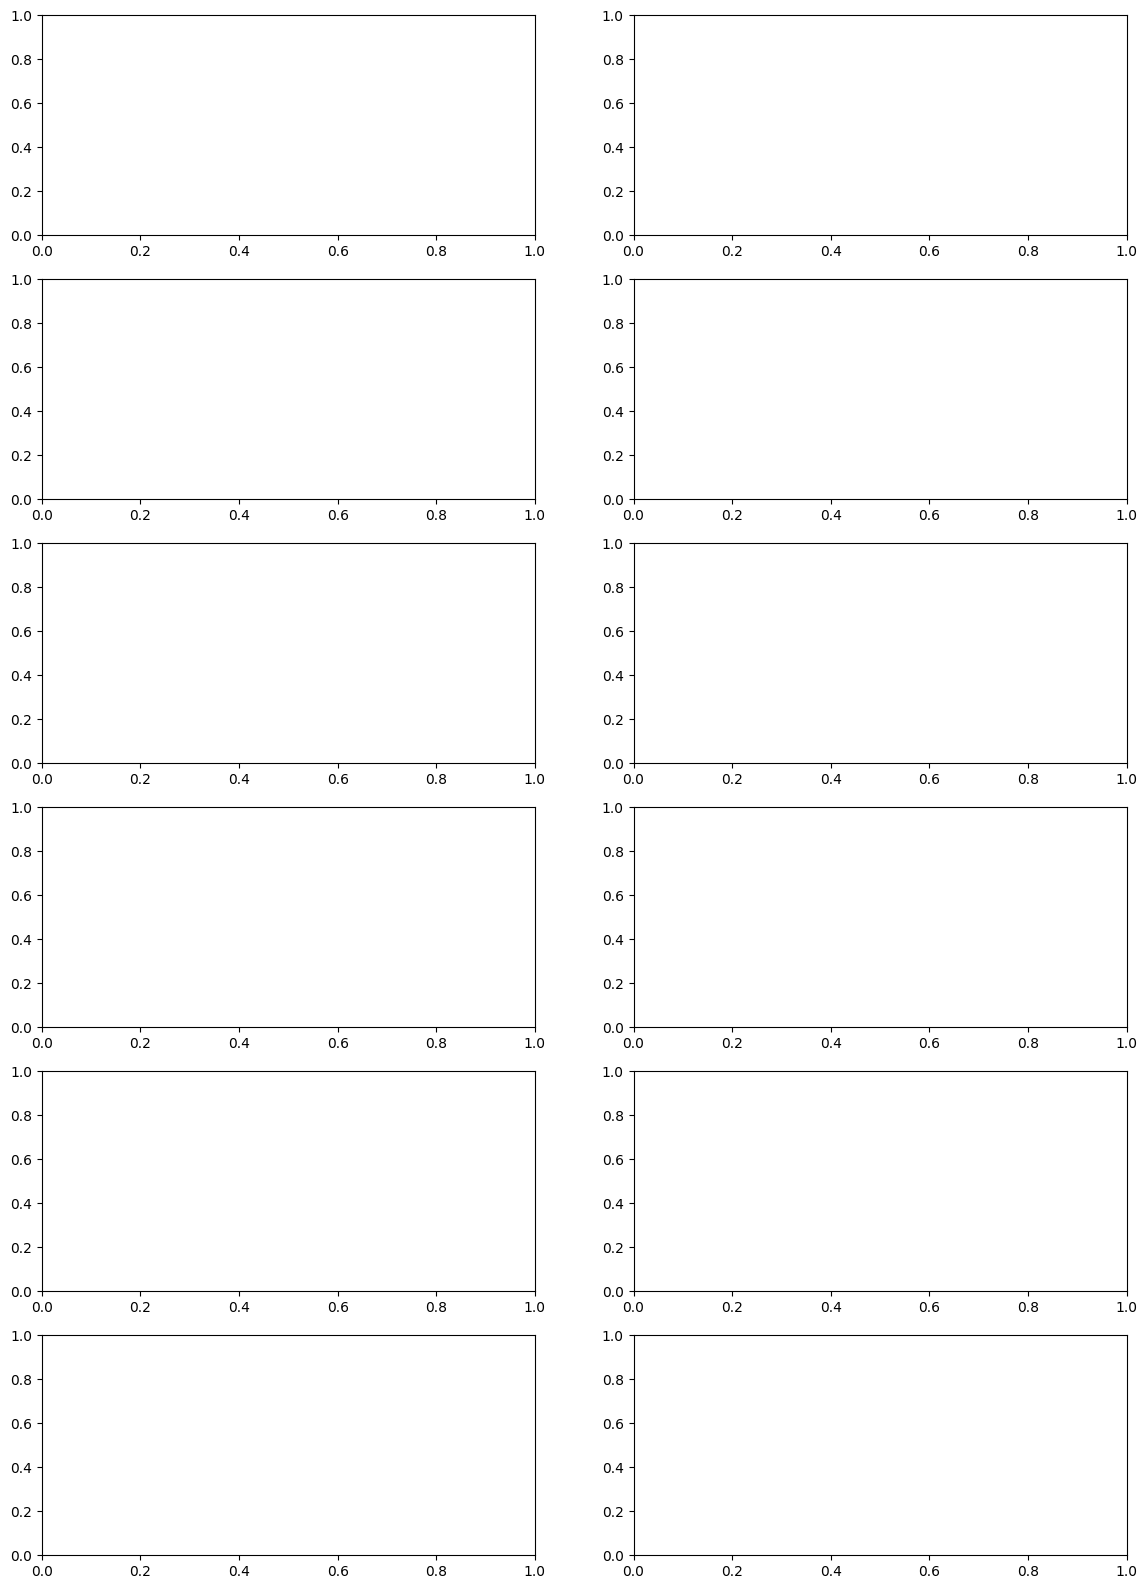

In [17]:
DATES = [
  { 'start_date': "2020-01-06", 'end_date': "2020-01-13" },
  { 'start_date': "2019-07-10", 'end_date': "2019-07-17" },
]

fig, axs = plt.subplots(6, 2, figsize=(14,20))

ax_y = 0
for d_ix, date_range in enumerate(DATES):
    start_date = date_range['start_date']
    end_date = date_range['end_date']

    ax_y = d_ix * 3
    
    for k_ix, key in enumerate(STATIONS.keys()):
      stn = STATIONS[key]
      dataset_observations = stn['dataset']
      time_slice_observed = dataset_observations.sel(time=slice(start_date, end_date))
    
      rh_model = extract_model_series('RH', start_date, end_date, stn['location'])
      rh_obs = time_slice_observed.relative_humidity
      plot_model_vs_observations(rh_model, rh_obs, key, start_date, 'RH', axs[ax_y+0][k_ix])  # 0, then 3
    
      # Model temperatures are in kelvin so need to be converted
      t_model = extract_model_series('T', start_date, end_date, stn['location'])
      t_model = t_model - 273.15
      t_obs = time_slice_observed.temperature
      plot_model_vs_observations(t_model, t_obs, key, start_date, 'T', axs[ax_y+1][k_ix]) # 1, then 4
    
      # Wind speed in the WRF data is in two directions and need to be combined
      u_model = extract_model_series('U', start_date, end_date, stn['location'])
      v_model = extract_model_series('V', start_date, end_date, stn['location'])
      ws_model = calc_wind_speed(u_model, v_model)
      ws_obs = time_slice_observed.wind_speed
      
      plot_model_vs_observations(ws_model, ws_obs, key, start_date, 'WS', axs[ax_y+2][k_ix]) # 2, then 5

plt.subplots_adjust(hspace=1.0)
plt.show()

### Discussion of the above results

# Part B